In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [33]:
df = pd.read_csv('../zuu crew scores.csv')
df = df[df['CourseName'] == 'Foundations of ML']
df.head()

,MemberName,EducationLevel,Attendance,TotalHours,AssignmentsCompleted,HackathonParticipation,GitHubScore,PeerReviewScore,CourseName,CapstoneScore
0,Theekshana Rathnayake,3,79.9,43.7,2,0,62.8,5.0,Foundations of ML,45.3
1,Mayura Sandakalum Sellapperuma,2,76.8,95.6,6,0,87.4,2.7,Foundations of ML,78.8
2,Amila Narangoda,3,96.6,75.9,8,0,98.4,2.8,Foundations of ML,65.4
4,Tharusha Vihanga,2,83.2,24.0,6,0,41.8,4.2,Foundations of ML,40.1
7,Chamath Perera,3,86.5,88.0,5,0,23.9,1.3,Foundations of ML,68.2


In [ ]:
X = df[ 'Attendance'].values.reshape(-1, 1)
Y = df[ 'CapstoneScore' ].values

Y_mean = np.mean(df['CapstoneScore'].values)
Y_std = np.std(df['CapstoneScore'].values)

X = (X_df - np.mean(X_df)) / np.std(X_df)
Y = (Y - np.mean(Y)) / np.std(Y)

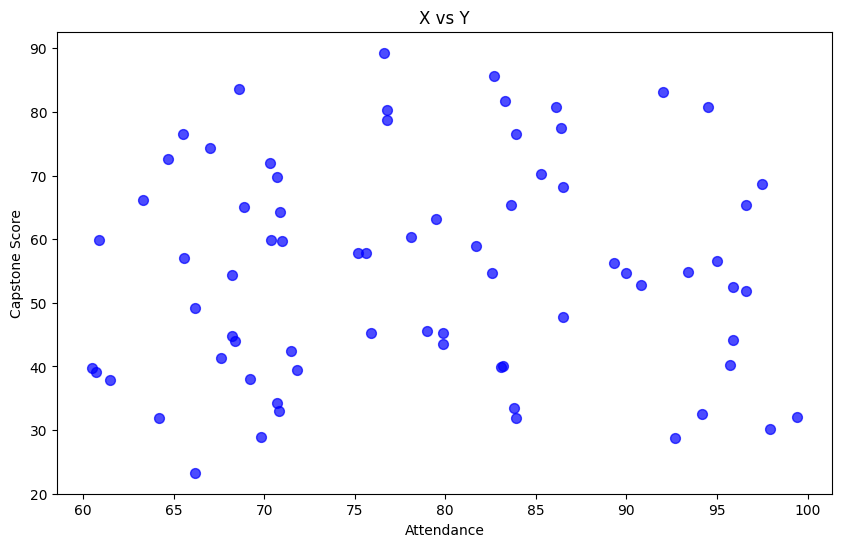

In [35]:
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, alpha=0.7, color='blue', s=50)
plt.xlabel('Attendance')
plt.ylabel('Capstone Score')
plt.title('X vs Y')
plt.show()

In [36]:
def compute_cost(X, Y, beta):
    m=len(Y)
    y_hat = X.dot(beta)
    cost = ( 1 / (2 * m) * np.sum((y_hat - Y) ** 2))
    return cost

In [45]:
def gradient_descent(X,Y,beta,n_iter,lr):
    m = len(Y)
    cost_history=[]

    for i in range(n_iter):
        y_hat = X.dot(beta) 
        gradient = (1/m) * X.T.dot(y_hat - Y)
        beta = beta - lr * gradient
        cost  = compute_cost(X,Y, beta)
        cost_history.append(cost)

        if i % 100 == 0:
            print(f"iteration: {i}, cost:{cost}, beta:{beta}")
    
    return beta

In [38]:
X_with_bias = np.column_stack([np.ones((len(X))), X])
beta = np.random.randn(2)
lr = 0.0001
n_iter = 10000


In [46]:
beta = gradient_descent(X_with_bias, Y, beta, n_iter, lr)

iteration: 0, cost:163.64186290537103, beta:[4.21359849 0.63398772]
iteration: 100, cost:163.63358067183557, beta:[4.22269847 0.63387457]
iteration: 200, cost:163.62530170414846, beta:[4.23179666 0.63376145]
iteration: 300, cost:163.61702600102177, beta:[4.24089305 0.63364835]
iteration: 400, cost:163.60875356116833, beta:[4.24998765 0.63353527]
iteration: 500, cost:163.60048438330128, beta:[4.25908045 0.63342221]
iteration: 600, cost:163.59221846613437, beta:[4.26817146 0.63330918]
iteration: 700, cost:163.58395580838186, beta:[4.27726068 0.63319617]
iteration: 800, cost:163.57569640875852, beta:[4.2863481  0.63308318]
iteration: 900, cost:163.56744026597957, beta:[4.29543374 0.63297021]
iteration: 1000, cost:163.55918737876075, beta:[4.30451758 0.63285727]
iteration: 1100, cost:163.55093774581837, beta:[4.31359963 0.63274435]
iteration: 1200, cost:163.5426913658692, beta:[4.32267989 0.63263145]
iteration: 1300, cost:163.53444823763053, beta:[4.33175836 0.63251857]
iteration: 1400, co

In [47]:
x_min, x_max = float(np.min(X)), float(np.max(X))
x_interval = np.linspace(x_min, x_max,100)
x_interval_with_bias = np.column_stack([np.ones((len(x_interval))), x_interval])
y_hat_interval = x_interval_with_bias.dot(beta)
y_hat_interval

array([42.79311812, 43.03782823, 43.28253833, 43.52724843, 43.77195853,
       44.01666864, 44.26137874, 44.50608884, 44.75079894, 44.99550905,
       45.24021915, 45.48492925, 45.72963935, 45.97434946, 46.21905956,
       46.46376966, 46.70847976, 46.95318987, 47.19789997, 47.44261007,
       47.68732017, 47.93203028, 48.17674038, 48.42145048, 48.66616058,
       48.91087069, 49.15558079, 49.40029089, 49.64500099, 49.8897111 ,
       50.1344212 , 50.3791313 , 50.6238414 , 50.86855151, 51.11326161,
       51.35797171, 51.60268181, 51.84739192, 52.09210202, 52.33681212,
       52.58152222, 52.82623233, 53.07094243, 53.31565253, 53.56036263,
       53.80507274, 54.04978284, 54.29449294, 54.53920304, 54.78391315,
       55.02862325, 55.27333335, 55.51804345, 55.76275356, 56.00746366,
       56.25217376, 56.49688386, 56.74159397, 56.98630407, 57.23101417,
       57.47572427, 57.72043438, 57.96514448, 58.20985458, 58.45456468,
       58.69927479, 58.94398489, 59.18869499, 59.43340509, 59.67

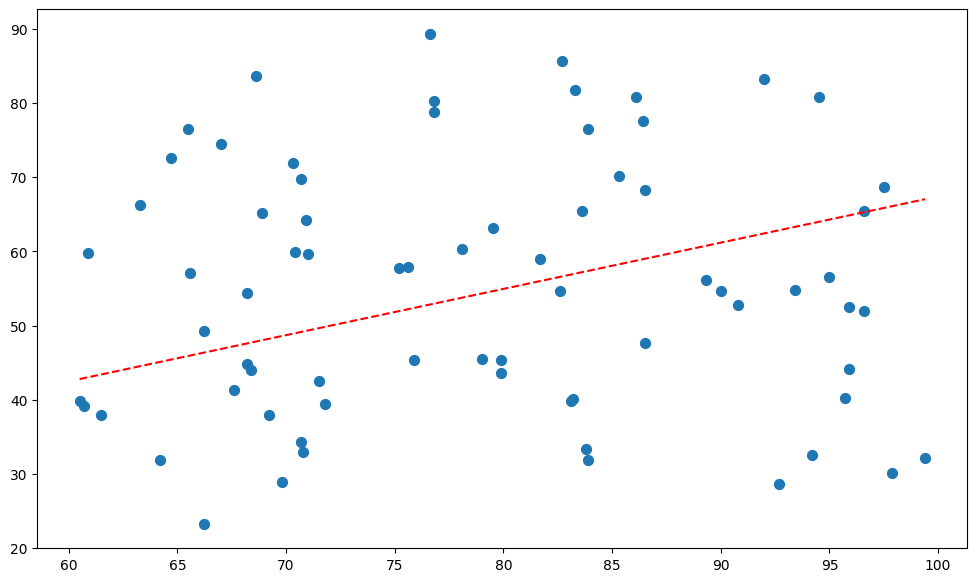

In [48]:
plt.figure(figsize=(12, 7))
plt.scatter(X, Y, s=50, label="actual data")
plt.plot(x_interval, y_hat_interval, 'r--', label="fitted line")
plt.show()

In [49]:
def Predict(X):
    X = np.array([1,X])
    y_predict = X.dot(beta)
    return y_predict

In [52]:
Predict(76.4)

np.float64(52.69538476522797)

In [53]:
Y_hat = X_with_bias.dot(beta)
Y_hat

array([54.87512899, 52.94449839, 65.27562289, 56.93031641, 58.98550383,
       52.81994158, 57.30398685, 61.16524806, 47.71311224, 64.83967404,
       47.58855543, 47.21488499, 43.41590219, 56.55664597, 53.75411768,
       46.3429873 , 63.96777635, 49.207794  , 46.3429873 , 58.92322542,
       48.02450427, 48.21133949, 45.09741917, 62.41081619, 58.7363902 ,
       63.78094113, 52.38399273, 47.58855543, 64.83967404, 42.79311812,
       56.99259482, 64.71511723, 62.84676503, 48.95868037, 51.94804389,
       57.17943004, 49.14551559, 49.83057806, 66.08524217, 54.62601537,
       43.04223175, 49.14551559, 55.99614031, 58.23816295, 48.89640197,
       45.96931686, 63.28271388, 67.01941827, 49.27007241, 42.91767494,
       45.4088112 , 56.868038  , 49.33235081, 45.90703845, 64.27916838,
       57.36626526, 46.84121455, 65.27562289, 52.94449839, 44.53691351,
       48.58500993, 52.19715751, 49.64374284, 56.61892438, 54.31462334,
       58.98550383, 65.83612855, 60.72929921, 47.83766905, 54.87

In [54]:
def MSE(Y,Y_hat):
    e_i = Y - Y_hat
    return np.mean(e_i**2)

def MAE(Y,Y_hat):
    e_i = Y - Y_hat
    return np.mean(np.abs(e_i))

def R2_Score(Y,Y_hat):
    y_mean = np.mean(Y)
    e_i = Y - Y_hat
    std_i = Y - y_mean

    E = np.sum(e_i**2) / np.sum(std_i ** 2)
    return 1 - E

def RMSE(Y,Y_hat):
    e_i = Y - Y_hat
    return np.sqrt(np.mean((Y - Y_hat) ** 2))           

In [55]:
mse = MSE(Y, Y_hat)
mae = MAE(Y, Y_hat)
r2 = R2_Score(Y, Y_hat)
rmse = RMSE(Y,Y_hat)

print(f"MSE : {mse}")
print(f"MAE : {mae}")
print(f"R2 Score : {r2}")
print(f"RMSE : {rmse}")

MSE : 325.65935775365404
MAE : 15.217029261480697
R2 Score : -0.13974977528290067
RMSE : 18.046034405199777
